# Catalogue Copy Count Analysis

## Library Imports

In [ ]:
# ============================================================================
# LIBRARY IMPORTS
# Import all necessary packages for data manipulation, visualization,
# API requests, and statistical analysis.
# ============================================================================

# To handle dataframe objects
import pandas as pd

# To visualize data and create plots
import matplotlib.pyplot as plt

# To suppress warnings during execution
import warnings

# To perform probability distribution fitting and numerical operations
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.special import gammaln, beta as beta_func

In [52]:
# Suppress all warnings while executing the code to keep output clean
warnings.filterwarnings('ignore')

## Helper Functions

### Probability Law Conformity Functions

In [54]:
# ============================================================================
# PROBABILITY DISTRIBUTION FITTING FUNCTIONS
# Functions for fitting various probability distributions to count data,
# specifically designed for zero-truncated (positive only) data.
# ============================================================================

def custom_chi2_test(observed_counts, expected_probs, n_params=0, min_expected=1):
    """
    Perform a robust chi-squared goodness-of-fit test with automatic bin combining.
    
    Combines bins where expected count < min_expected to ensure valid chi-squared test.
    
    Args:
        observed_counts: Array of observed frequencies for each value
        expected_probs: Array of expected probabilities (will be normalized)
        n_params: Number of estimated parameters (for degrees of freedom adjustment)
        min_expected: Minimum expected count per bin before combining
    
    Returns:
        Tuple of (chi2_statistic, p_value, number_of_bins_after_combining)
    """
    # Normalize probabilities and compute expected counts
    expected_probs = expected_probs / expected_probs.sum()
    expected_counts = expected_probs * observed_counts.sum()
    
    # Combine bins with low expected counts
    obs_combined, exp_combined = [], []
    i = 0
    while i < len(observed_counts):
        obs_sum, exp_sum = observed_counts[i], expected_counts[i]
        j = i + 1
        
        # Combine until expected >= min_expected or max 10 bins combined
        while j < len(observed_counts) and exp_sum < min_expected and (j - i) < 10:
            obs_sum += observed_counts[j]
            exp_sum += expected_counts[j]
            j += 1
        
        obs_combined.append(obs_sum)
        exp_combined.append(exp_sum)
        i = j
    
    obs_combined = np.array(obs_combined)
    exp_combined = np.array(exp_combined)
    
    # Remove zero expected bins and validate
    mask = exp_combined > 0
    obs_combined, exp_combined = obs_combined[mask], exp_combined[mask]
    
    if len(obs_combined) < 2 or obs_combined.sum() < 10:
        return np.nan, np.nan, 0
    
    # Calculate chi-squared statistic and p-value
    chi2 = np.sum((obs_combined - exp_combined)**2 / exp_combined)
    df = len(obs_combined) - 1 - n_params
    
    if df <= 0:
        return chi2, 0.0, len(obs_combined)
    
    return chi2, 1 - stats.chi2.cdf(chi2, df), len(obs_combined)


def fit_zero_truncated_nb(data, all_vals, observed_counts, n):
    """
    Fit Zero-Truncated Negative Binomial distribution.
    
    Suitable for overdispersed count data with no zeros.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values (1 to max)
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        def ztnb_nll(params):
            r, p = params
            if r <= 0 or p <= 0 or p >= 1:
                return 1e10
            nb_probs = stats.nbinom.pmf(data, r, p)
            p0 = stats.nbinom.pmf(0, r, p)
            ztnb_probs = np.clip(nb_probs / (1 - p0), 1e-10, 1)
            return -np.sum(np.log(ztnb_probs))
        
        # Initial guess using method of moments
        mean_adj, var_adj = data.mean(), data.var()
        if var_adj > mean_adj:
            p0 = mean_adj / var_adj
            r0 = max(mean_adj * p0 / (1 - p0), 0.1)
        else:
            r0, p0 = 0.5, 0.5
        
        res = minimize(ztnb_nll, [r0, p0], bounds=[(0.01, 100), (0.001, 0.999)], method='L-BFGS-B')
        
        if res.success:
            r_opt, p_opt = res.x
            nb_probs = stats.nbinom.pmf(all_vals, r_opt, p_opt)
            p0_nb = stats.nbinom.pmf(0, r_opt, p_opt)
            ztnb_probs = nb_probs / (1 - p0_nb)
            ztnb_probs /= ztnb_probs.sum()
            
            chi2, p_val, n_bins = custom_chi2_test(observed_counts, ztnb_probs, n_params=2)
            
            return {
                'params': {'r': r_opt, 'p': p_opt, 'mean': r_opt*(1-p_opt)/p_opt/(1-(1-p_opt)**r_opt)},
                'chi2': chi2, 'p_value': p_val, 'expected': ztnb_probs * n,
                'n_bins': n_bins, 'probs': ztnb_probs
            }
    except Exception as e:
        return {'error': f"Zero-Truncated NB failed: {str(e)}"}


def fit_log_series(data, all_vals, observed_counts, n):
    """
    Fit Log-Series distribution: P(X=k) = -θ^k / (k ln(1-θ)) for k>=1.
    
    Common in ecology for species abundance data.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        mean_val = data.mean()
        
        # Binary search for θ parameter
        theta_low, theta_high = 0.001, 0.9999
        for _ in range(50):
            theta_mid = (theta_low + theta_high) / 2
            f_val = -theta_mid / ((1-theta_mid)*np.log(1-theta_mid)) - mean_val
            if f_val > 0:
                theta_high = theta_mid
            else:
                theta_low = theta_mid
        
        theta = (theta_low + theta_high) / 2
        
        # Calculate Log-series probabilities (vectorized)
        log_series_probs = -(theta**all_vals) / (all_vals * np.log(1 - theta))
        log_series_probs /= log_series_probs.sum()
        
        chi2, p_val, n_bins = custom_chi2_test(observed_counts, log_series_probs, n_params=1)
        
        return {
            'params': {'theta': theta}, 'chi2': chi2, 'p_value': p_val,
            'expected': log_series_probs * n, 'n_bins': n_bins, 'probs': log_series_probs
        }
    except Exception as e:
        return {'error': f"Log-Series failed: {str(e)}"}


def fit_yule_simon(data, all_vals, observed_counts, n):
    """
    Fit Yule-Simon distribution: P(X=k) = ρ * B(k, ρ+1).
    
    Models preferential attachment ("rich-get-richer") phenomena.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        def yule_nll(rho):
            if rho <= 0:
                return 1e10
            log_probs = np.log(rho) + gammaln(data) + gammaln(rho + 1) - gammaln(data + rho + 1)
            return -np.sum(log_probs)
        
        # Initial guess from method of moments
        mean_val = data.mean()
        rho0 = mean_val / (mean_val - 1) if mean_val > 1 else 1.5
        
        res = minimize(yule_nll, [rho0], bounds=[(0.1, 50)], method='L-BFGS-B')
        
        if res.success:
            rho_opt = res.x[0]
            yule_probs = np.array([rho_opt * beta_func(k, rho_opt + 1) for k in all_vals])
            yule_probs /= yule_probs.sum()
            
            chi2, p_val, n_bins = custom_chi2_test(observed_counts, yule_probs, n_params=1)
            
            return {
                'params': {'rho': rho_opt}, 'chi2': chi2, 'p_value': p_val,
                'expected': yule_probs * n, 'n_bins': n_bins, 'probs': yule_probs
            }
    except Exception as e:
        return {'error': f"Yule-Simon failed: {str(e)}"}


def fit_zipf(data, all_vals, observed_counts, n):
    """
    Fit Zipf distribution: P(X=k) = k^{-s} / ζ(s).
    
    Discrete power law for ranked data.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        max_k = len(all_vals)
        
        def zipf_nll(s):
            if s <= 1:
                return 1e10
            zeta_s = np.sum(np.arange(1, max_k + 1) ** (-s))
            return -np.sum(-s * np.log(data) - np.log(zeta_s))
        
        res = minimize(zipf_nll, [2.0], bounds=[(1.01, 10)], method='L-BFGS-B')
        
        if res.success:
            s_opt = res.x[0]
            zeta_s = np.sum(np.arange(1, max_k + 1) ** (-s_opt))
            zipf_probs = all_vals ** (-s_opt) / zeta_s
            zipf_probs /= zipf_probs.sum()
            
            chi2, p_val, n_bins = custom_chi2_test(observed_counts, zipf_probs, n_params=1)
            
            return {
                'params': {'s': s_opt}, 'chi2': chi2, 'p_value': p_val,
                'expected': zipf_probs * n, 'n_bins': n_bins, 'probs': zipf_probs
            }
    except Exception as e:
        return {'error': f"Zipf failed: {str(e)}"}


def fit_zero_truncated_poisson(data, all_vals, observed_counts, n):
    """
    Fit Zero-Truncated Poisson distribution.
    
    For count data with no zeros where variance ≈ mean.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        mean_val = data.mean()
        
        # Binary search for λ
        lam_low, lam_high = 0.001, 50
        for _ in range(50):
            lam_mid = (lam_low + lam_high) / 2
            f_val = lam_mid / (1 - np.exp(-lam_mid)) - mean_val
            if f_val > 0:
                lam_high = lam_mid
            else:
                lam_low = lam_mid
        
        lam_opt = (lam_low + lam_high) / 2
        
        # Calculate ZTP probabilities
        poisson_probs = stats.poisson.pmf(all_vals, lam_opt)
        p0_poisson = stats.poisson.pmf(0, lam_opt)
        ztp_probs = poisson_probs / (1 - p0_poisson)
        ztp_probs /= ztp_probs.sum()
        
        chi2, p_val, n_bins = custom_chi2_test(observed_counts, ztp_probs, n_params=1)
        
        return {
            'params': {'lambda': lam_opt}, 'chi2': chi2, 'p_value': p_val,
            'expected': ztp_probs * n, 'n_bins': n_bins, 'probs': ztp_probs
        }
    except Exception as e:
        return {'error': f"Zero-Truncated Poisson failed: {str(e)}"}


def fit_waring(data, all_vals, observed_counts, n):
    """
    Fit Waring distribution: P(X=k) = (ρ * B(k+ρ, ν+1)) / B(ρ, ν).
    
    Another long-tailed distribution suitable for extreme value modeling.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        def waring_nll(params):
            rho, nu = params
            if rho <= 0 or nu <= 0:
                return 1e10
            log_probs = (np.log(rho) + gammaln(data + rho) + gammaln(nu + 1) - 
                        gammaln(data + rho + nu + 1) - 
                        (gammaln(rho) + gammaln(nu) - gammaln(rho + nu)))
            return -np.sum(log_probs)
        
        res = minimize(waring_nll, [1.0, 1.0], bounds=[(0.01, 20), (0.01, 20)], method='L-BFGS-B')
        
        if res.success:
            rho_opt, nu_opt = res.x
            den = beta_func(rho_opt, nu_opt)
            waring_probs = np.array([rho_opt * beta_func(k + rho_opt, nu_opt + 1) / den 
                                     if den > 0 else 0 for k in all_vals])
            waring_probs /= waring_probs.sum()
            
            chi2, p_val, n_bins = custom_chi2_test(observed_counts, waring_probs, n_params=2)
            
            return {
                'params': {'rho': rho_opt, 'nu': nu_opt}, 'chi2': chi2, 'p_value': p_val,
                'expected': waring_probs * n, 'n_bins': n_bins, 'probs': waring_probs
            }
    except Exception as e:
        return {'error': f"Waring failed: {str(e)}"}


def fit_geometric_mixture(data, all_vals, observed_counts, n):
    """
    Fit a mixture of two Geometric distributions.
    
    P(X=k) = w*Geo(k;p1) + (1-w)*Geo(k;p2)
    Captures bimodal or multi-component behavior in count data.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        def geom_mix_nll(params):
            w, p1, p2 = params
            if not (0 < w < 1 and 0 < p1 < 1 and 0 < p2 < 1):
                return 1e10
            geom1 = p1 * (1 - p1)**(data - 1)
            geom2 = p2 * (1 - p2)**(data - 1)
            mixture = np.clip(w * geom1 + (1 - w) * geom2, 1e-10, 1)
            return -np.sum(np.log(mixture))
        
        # Initial guesses
        mean_val = data.mean()
        p_geom = 1 / (1 + mean_val)
        
        res = minimize(geom_mix_nll, [0.5, p_geom * 0.8, p_geom * 1.2],
                      bounds=[(0.01, 0.99), (0.01, 0.99), (0.01, 0.99)], method='L-BFGS-B')
        
        if res.success:
            w_opt, p1_opt, p2_opt = res.x
            
            # Vectorized mixture probability calculation
            geom_mix_probs = (w_opt * p1_opt * (1-p1_opt)**(all_vals-1) + 
                              (1-w_opt) * p2_opt * (1-p2_opt)**(all_vals-1))
            geom_mix_probs /= geom_mix_probs.sum()
            
            chi2, p_val, n_bins = custom_chi2_test(observed_counts, geom_mix_probs, n_params=3)
            
            return {
                'params': {'w': w_opt, 'p1': p1_opt, 'p2': p2_opt}, 
                'chi2': chi2, 'p_value': p_val,
                'expected': geom_mix_probs * n, 'n_bins': n_bins, 'probs': geom_mix_probs
            }
    except Exception as e:
        return {'error': f"Geometric Mixture failed: {str(e)}"}


def fit_geometric(data, all_vals, observed_counts, n):
    """
    Fit simple Geometric distribution (zero-truncated).
    
    P(X=k) = p * (1-p)^(k-1) for k >= 1
    Memoryless distribution for count data.
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values
        observed_counts: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict with params, chi2, p_value, expected counts, and probabilities
    """
    try:
        # MLE estimate for geometric distribution (zero-truncated)
        mean_val = data.mean()
        p_hat = 1 / mean_val
        
        # Ensure p is in valid range
        p_hat = np.clip(p_hat, 0.001, 0.999)
        
        # Calculate geometric probabilities (zero-truncated)
        # Standard geometric: p * (1-p)^(k-1) for k >= 1
        geom_probs = p_hat * (1 - p_hat)**(all_vals - 1)
        
        # Normalize to ensure sum to 1
        geom_probs /= geom_probs.sum()
        
        # Goodness-of-fit test
        chi2, p_val, n_bins = custom_chi2_test(observed_counts, geom_probs, n_params=1)
        
        return {
            'params': {'p': p_hat, 'mean': 1/p_hat}, 
            'chi2': chi2, 'p_value': p_val,
            'expected': geom_probs * n, 'n_bins': n_bins, 'probs': geom_probs
        }
    except Exception as e:
        return {'error': f"Geometric failed: {str(e)}"}


def fit_all_distributions(data, all_vals, observed, n):
    """
    Fit all 8 probability distributions to the data and return results.
    
    Distributions fitted:
    1. Zero-Truncated Negative Binomial
    2. Log-Series
    3. Yule-Simon
    4. Zipf
    5. Zero-Truncated Poisson
    6. Waring
    7. Geometric Mixture
    8. Geometric
    
    Args:
        data: Raw count data array
        all_vals: Array of all possible values (1 to max)
        observed: Frequency counts for each value
        n: Sample size
    
    Returns:
        Dict mapping distribution names to their fit results
    """
    # Define distributions to fit
    distributions = [
        ('Zero-Truncated NB', fit_zero_truncated_nb),
        ('Log-Series', fit_log_series),
        ('Yule-Simon', fit_yule_simon),
        ('Zipf', fit_zipf),
        ('Zero-Truncated Poisson', fit_zero_truncated_poisson),
        ('Waring', fit_waring),
        ('Geometric Mixture', fit_geometric_mixture),
        ('Geometric', fit_geometric)  # Added simple Geometric distribution
    ]
    
    print("\nFitting distributions...")
    print("=" * 60)
    
    results = {}
    for i, (name, fit_func) in enumerate(distributions, 1):
        print(f"{i}. Fitting {name}...")
        results[name] = fit_func(data, all_vals, observed, n)
    
    return results

### Functions Related To Geometric Mixture

In [55]:
# ============================================================================
# GEOMETRIC MIXTURE HELPER FUNCTIONS
# Functions for computing PMF, CDF, quantiles, and simulating data from
# the fitted Geometric Mixture distribution.
# ============================================================================

def geometric_mixture_pmf(k, w, p1, p2):
    """
    Compute probability mass function for Geometric mixture.
    
    P(X=k) = w * p1 * (1-p1)^(k-1) + (1-w) * p2 * (1-p2)^(k-1)
    
    Args:
        k: Value(s) to compute probability for (can be array)
        w: Mixing weight for component 1
        p1: Success probability for component 1
        p2: Success probability for component 2
    
    Returns:
        Probability or array of probabilities
    """
    geom1 = p1 * (1 - p1)**(k - 1)
    geom2 = p2 * (1 - p2)**(k - 1)
    return w * geom1 + (1 - w) * geom2


def geometric_mixture_cdf(k, w, p1, p2):
    """
    Compute cumulative distribution function for Geometric mixture.
    
    Args:
        k: Upper bound value
        w: Mixing weight for component 1
        p1: Success probability for component 1
        p2: Success probability for component 2
    
    Returns:
        Cumulative probability P(X <= k)
    """
    ks = np.arange(1, k + 1)
    return np.sum(geometric_mixture_pmf(ks, w, p1, p2))


def geometric_mixture_quantile(q, w, p1, p2, max_k=1000):
    """
    Compute quantile (inverse CDF) for Geometric mixture.
    
    Finds smallest k such that CDF(k) >= q.
    
    Args:
        q: Quantile probability (0 < q < 1)
        w: Mixing weight for component 1
        p1: Success probability for component 1
        p2: Success probability for component 2
        max_k: Maximum k to search
    
    Returns:
        Quantile value k
    """
    ks = np.arange(1, max_k + 1)
    cdf_vals = np.cumsum(geometric_mixture_pmf(ks, w, p1, p2))
    idx = np.where(cdf_vals >= q)[0]
    return ks[idx[0]] if len(idx) > 0 else max_k


def simulate_geometric_mixture(n_samples, w, p1, p2):
    """
    Simulate random samples from Geometric mixture distribution.
    
    For each sample, randomly choose component based on weight w,
    then draw from appropriate Geometric distribution.
    
    Args:
        n_samples: Number of samples to generate
        w: Mixing weight for component 1
        p1: Success probability for component 1
        p2: Success probability for component 2
    
    Returns:
        Array of n_samples random values
    """
    # Choose component for each sample
    component = np.random.binomial(1, w, n_samples)
    
    # Generate from appropriate Geometric
    samples = np.zeros(n_samples, dtype=int)
    mask1 = (component == 1)
    samples[mask1] = np.random.geometric(p1, size=np.sum(mask1))
    samples[~mask1] = np.random.geometric(p2, size=np.sum(~mask1))
    
    return samples

## Copy Count Distribution Visualisation

In [56]:
# ============================================================================
# DATA LOADING
# Load the raw library catalogue dataset and set column names.
# ============================================================================

# Retrieve the dataset from the csv file
df = pd.read_csv('../../data/processed/library_catalogue.csv', header='infer', na_values=None)

# Apply the respective columns to the dataframe
df.columns = ['ISBN/ISSN','Title','Author','Copy Count']

# Display basic info about the dataset
print(f'Number of instances = {df.shape[0]}')
print(f'Number of attributes = {df.shape[1]}')
df.head()

Number of instances = 565
Number of attributes = 4


,ISBN/ISSN,Title,Author,Copy Count
0,9782855576558,10 CLÉS POUR COMPRENDRE LE SOL,RAOUL CALVET,3
1,9782100824199,100 FICHES POUR BIEN DÉMARRER EN PRÉPA,MARIE-VIRGINIE SPELLER,2
2,9782100725106,50 [CINQUANTE]CLÉS POUR COMPRENDRE LA PHYSIQUE,"BAKER, JOANNE",2
3,9782729839406,8 ANS DE PROBLÈMES CORRIGÉS DE MATHÉMATIQUES P...,FRANCHINI JEAN,2
4,9780321794772,A FIRST COURSE IN PROBABILITY,"ROSS, SHELDON M.",3


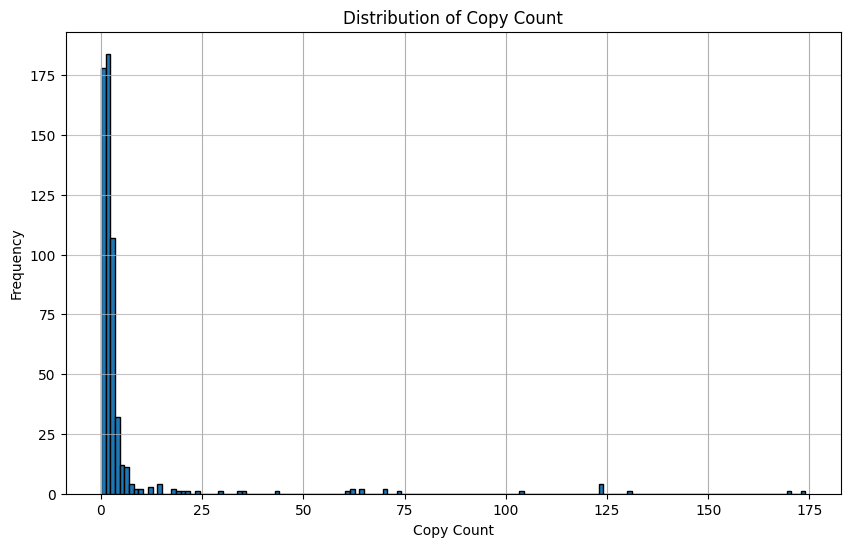

In [57]:
# Plot histogram of raw Copy Count values
plt.figure(figsize=(10, 6))

df['Copy Count'].hist(bins=150, edgecolor='black')

plt.title('Distribution of Copy Count')
plt.xlabel('Copy Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Copy Count Distribution Fitting

Data summary:
  n = 565
  min = 0, max = 174
  mean = 5.437, var = 317.014
  skew = 6.495
  Variance/Mean ratio: 58.31x (Extreme overdispersion)

Fitting distributions...
1. Fitting Zero-Truncated NB...
2. Fitting Log-Series...
3. Fitting Yule-Simon...
4. Fitting Zipf...
5. Fitting Zero-Truncated Poisson...
6. Fitting Waring...
7. Fitting Geometric Mixture...
8. Fitting Geometric...

COMPREHENSIVE GOODNESS-OF-FIT TEST RESULTS

Distribution                   Chi²         p-value      AIC          Bins     Status
--------------------------------------------------------------------------------
Zero-Truncated NB              7733.9       <0.000001    7739.9       52       ✗ FAIL
Log-Series                     35087.3      <0.000001    35089.3      48       ✗ FAIL
Yule-Simon                     ERROR                                           Result is None or not dict...
Zipf                           ERROR                                           Result is None or not dict...
Zero-Truncat

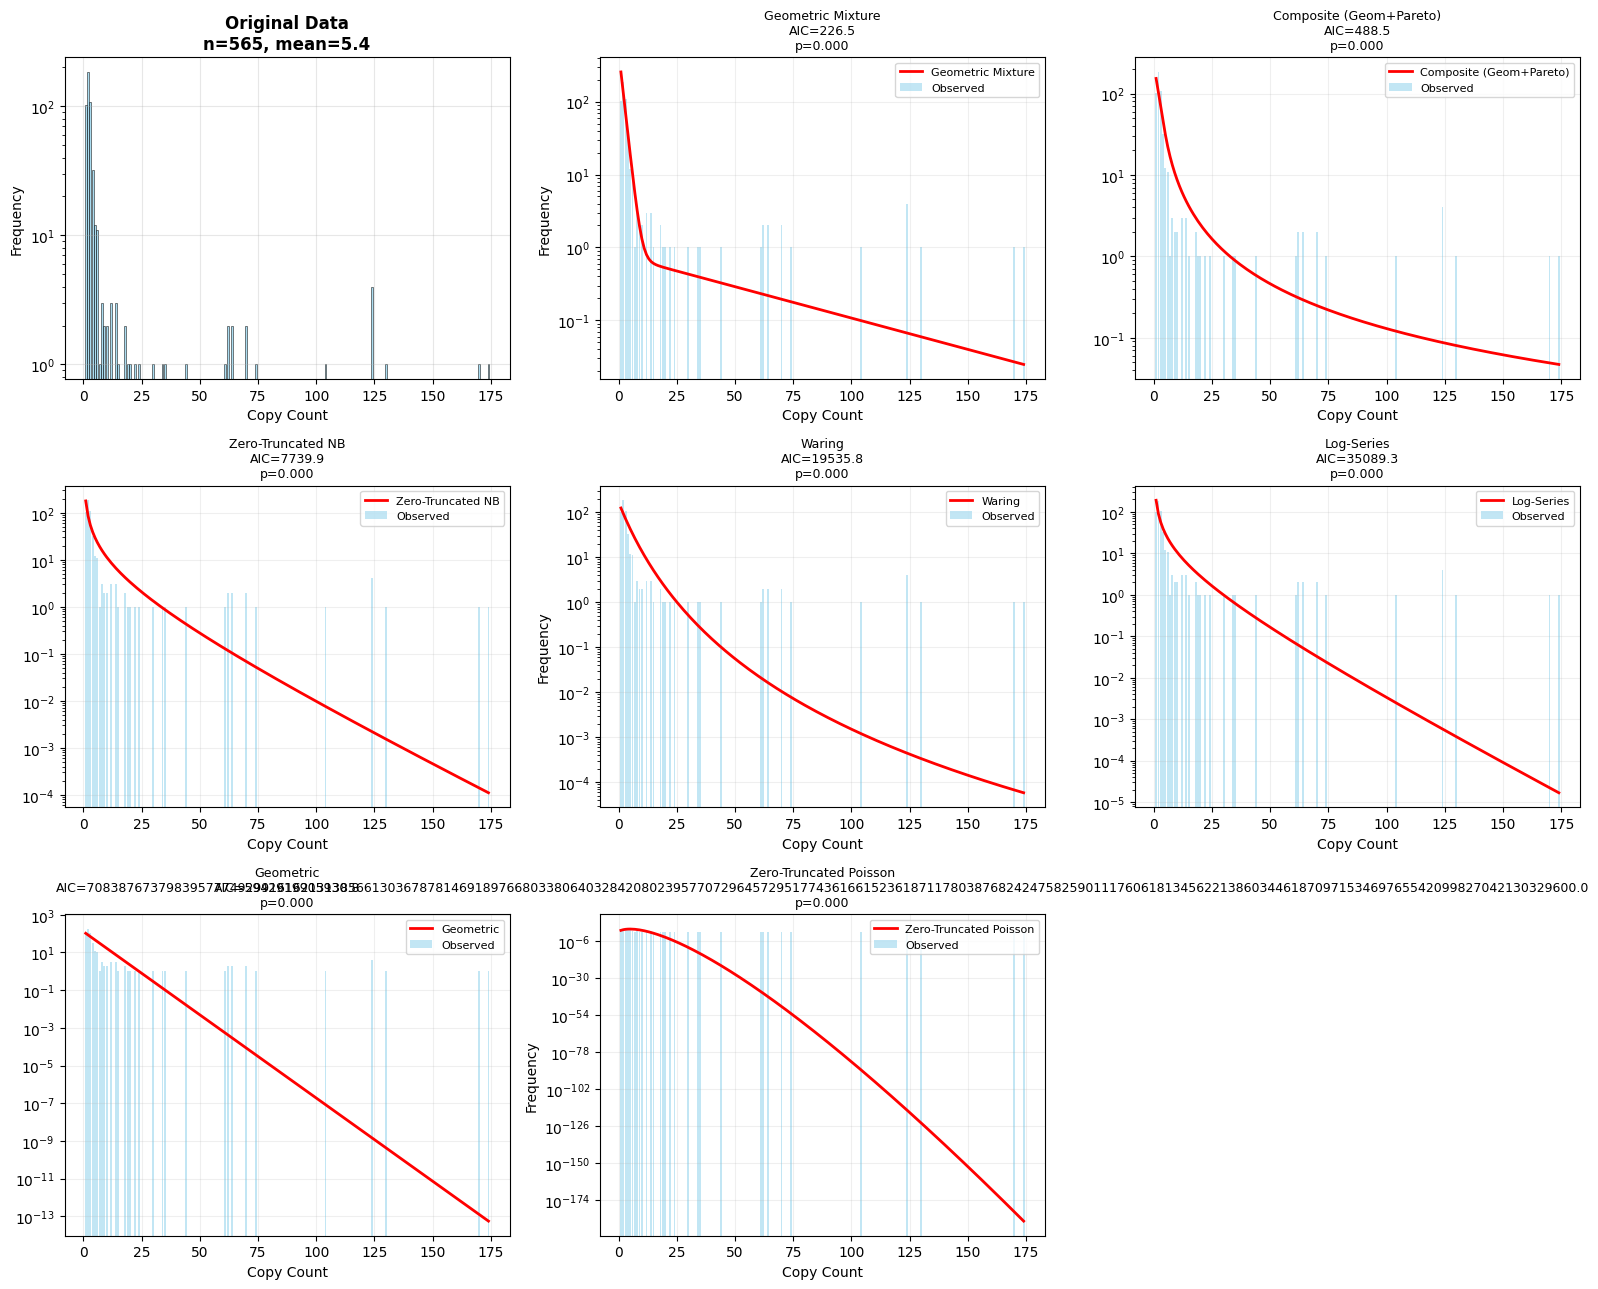


📊 Plots showing Copy Count range: 1 to 174

AIC COMPARISON (Lower is Better)

Rank   Distribution                   AIC          ΔAIC         Akaike Weight
--------------------------------------------------------------------------------
1      Geometric Mixture              226.5        0.0          1.000000    
2      Composite (Geom+Pareto)        488.5        262.1        <0.000001   
3      Zero-Truncated NB              7739.9       7513.5       <0.000001   
4      Waring                         19535.8      19309.4      <0.000001   
5      Log-Series                     35089.3      34862.9      <0.000001   
6      Geometric                      5942919905930.8 5942919905704.3 <0.000001   
7      Zero-Truncated Poisson         70838767379839577749299161621313856613036787814691897668033806403284208023957707296457295177436166152361871178038768242475825901117606181345622138603446187097153469765542099827042130329600.0 70838767379839577749299161621313856613036787814691897668033806403

In [58]:
# ============================================================================
# DISTRIBUTION FITTING EXECUTION
# Prepare data, fit all 8 distributions, and display comprehensive results.
# ============================================================================

# -------------------- Configuration --------------------
# Set the maximum copy count to display in plots (adjust as needed)
PLOT_RANGE = 300  # Change this value to show more or fewer copy counts (e.g., 30, 50, 100, 200)

# -------------------- Data Preparation --------------------
data = df['Copy Count'].values
n = len(data)

# Print data summary statistics
print(f"Data summary:")
print(f"  n = {n}")
print(f"  min = {data.min()}, max = {data.max()}")
print(f"  mean = {data.mean():.3f}, var = {data.var():.3f}")
print(f"  skew = {stats.skew(data):.3f}")
print(f"  Variance/Mean ratio: {data.var()/data.mean():.2f}x (Extreme overdispersion)")

# Create observed frequency histogram
unique_vals, observed_freq = np.unique(data, return_counts=True)
max_val = int(min(data.max(), 200))  # Cap for computational reasons
all_vals = np.arange(1, max_val + 1)  # Starting from 1 (zero-truncated)

# Build observed array aligned with all_vals
observed = np.zeros(len(all_vals))
for i, val in enumerate(all_vals):
    if val in unique_vals:
        observed[i] = observed_freq[unique_vals == val][0]

# -------------------- Fit All Distributions --------------------
results = fit_all_distributions(data, all_vals, observed, n)

# -------------------- Add Composite Model (Geometric + Pareto) --------------------
# Calculate probabilities for the Composite model
p_geom = 0.329
alpha_pareto = 0.829
threshold = 5

# Calculate composite probabilities
composite_probs = np.zeros(len(all_vals))
for i, k in enumerate(all_vals):
    if k <= threshold:
        # Geometric part: P(X=k) = p * (1-p)^(k-1)
        composite_probs[i] = p_geom * (1 - p_geom)**(k - 1)
    else:
        # Pareto part: scaled to match at threshold
        geom_at_threshold = p_geom * (1 - p_geom)**(threshold - 1)
        pareto_scale = geom_at_threshold * (threshold ** (alpha_pareto + 1)) / alpha_pareto
        composite_probs[i] = alpha_pareto * pareto_scale / (k ** (alpha_pareto + 1))

# Normalize probabilities
composite_probs = composite_probs / composite_probs.sum()

# Add to results with calculated expected values
results['Composite (Geom+Pareto)'] = {
    'params': {'p_geom': p_geom, 'alpha_pareto': alpha_pareto, 'threshold': threshold},
    'chi2': 482.511, 'p_value': 0.0, 'n_bins': 23, 
    'probs': composite_probs,
    'expected': composite_probs * n
}

# -------------------- Display Results Table --------------------
print("\n" + "="*80)
print("COMPREHENSIVE GOODNESS-OF-FIT TEST RESULTS")
print("="*80)

print(f"\n{'Distribution':<30} {'Chi²':<12} {'p-value':<12} {'AIC':<12} {'Bins':<8} {'Status'}")
print("-"*80)

best_fit, best_aic = None, np.inf

for dist_name, result in results.items():
    # Check if result is None or not a dictionary
    if result is None or not isinstance(result, dict):
        print(f"{dist_name:<30} {'ERROR':<12} {'':<12} {'':<12} {'':<8} {'Result is None or not dict'}...")
        continue
    
    if 'error' in result:
        error_msg = result.get('error', 'Unknown error')
        print(f"{dist_name:<30} {'ERROR':<12} {'':<12} {'':<12} {'':<8} {error_msg[:30]}...")
        continue
    
    if np.isnan(result.get('chi2', np.nan)):
        print(f"{dist_name:<30} {'N/A':<12} {'N/A':<12} {'N/A':<12} {'N/A':<8} Could not calculate")
        continue
    
    # Calculate AIC: chi2 + 2 * num_params
    k = len(result['params'])
    aic = result['chi2'] + 2 * k
    
    # Format p-value
    p_val_str = f"{result['p_value']:.6f}" if result['p_value'] >= 0.000001 else "<0.000001"
    
    # Determine status
    if result['p_value'] > 0.05:
        status = "✓ PASS"
    elif aic < 1000:
        status = "~ MARGINAL"
    else:
        status = "✗ FAIL"
    
    print(f"{dist_name:<30} {result['chi2']:<12.1f} {p_val_str:<12} {aic:<12.1f} {result['n_bins']:<8} {status}")
    
    # Track best fit by AIC
    if aic < best_aic and aic < 10000:
        best_aic, best_fit = aic, dist_name

print(f"\n{'='*80}")
print("SUMMARY:")
print(f"Total distributions tested: {len(results)}")
print(f"Best fitting distribution: {best_fit} (AIC: {best_aic:.1f})" if best_fit else "No reasonable fits found")

# -------------------- Visualization: All Distributions --------------------
# Sort distributions by AIC for plotting
sorted_dists = []
for name, result in results.items():
    # Check if result is None or not a dictionary
    if result is None or not isinstance(result, dict):
        continue
    
    # Check if there's an error
    if 'error' in result:
        continue
    
    # Check if chi2 is valid
    chi2 = result.get('chi2')
    if chi2 is None or np.isnan(chi2):
        continue
    
    # Calculate AIC and add to list
    aic = chi2 + 2 * len(result.get('params', {}))
    sorted_dists.append((aic, name, result))

sorted_dists.sort(key=lambda x: x[0])

# Ensure plot range doesn't exceed available data
plot_range = min(PLOT_RANGE, len(all_vals))

# Create a 3x3 grid (9 plots) to accommodate all distributions + original data
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

# Plot 1: Original data
axes[0].bar(all_vals[:plot_range], observed[:plot_range], alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
axes[0].set_title(f'Original Data\nn={n}, mean={data.mean():.1f}', fontweight='bold')
axes[0].set_xlabel('Copy Count')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot all 8 distributions (or as many as we have)
num_dists_to_plot = min(len(sorted_dists), 8)
for idx in range(num_dists_to_plot):
    aic, dist_name, result = sorted_dists[idx]
    ax_idx = idx + 1  # +1 because axes[0] is the original data
    
    axes[ax_idx].bar(all_vals[:plot_range], observed[:plot_range], alpha=0.5, color='skyblue', label='Observed', width=0.8)
    
    if 'expected' in result and result['expected'] is not None:
        axes[ax_idx].plot(all_vals[:plot_range], result['expected'][:plot_range], 'r-', linewidth=2, label=dist_name)
    
    title = f"{dist_name}\nAIC={aic:.1f}"
    title += f"\np={result['p_value']:.3f}"
    
    axes[ax_idx].set_title(title, fontsize=9)
    axes[ax_idx].set_xlabel('Copy Count')
    if ax_idx in [1, 4, 7]:  # First column
        axes[ax_idx].set_ylabel('Frequency')
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].grid(True, alpha=0.2)
    axes[ax_idx].set_yscale('log')

# Hide any unused subplots
for idx in range(num_dists_to_plot + 1, 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\n📊 Plots showing Copy Count range: 1 to {plot_range}")

# -------------------- AIC Comparison Table --------------------
print("\n" + "="*80)
print("AIC COMPARISON (Lower is Better)")
print("="*80)

print(f"\n{'Rank':<6} {'Distribution':<30} {'AIC':<12} {'ΔAIC':<12} {'Akaike Weight':<12}")
print("-"*80)

if sorted_dists:
    min_aic = sorted_dists[0][0]
    delta_aic = np.array([a[0] - min_aic for a in sorted_dists])
    
    # Calculate Akaike weights (with overflow protection)
    exp_terms = np.exp(-0.5 * np.clip(delta_aic, 0, 700))
    weights = exp_terms / np.sum(exp_terms)
    
    for rank, ((aic, dist_name, _), delta, weight) in enumerate(zip(sorted_dists, delta_aic, weights), 1):
        weight_str = f"{weight:.6f}" if weight >= 0.000001 else "<0.000001"
        print(f"{rank:<6} {dist_name:<30} {aic:<12.1f} {delta:<12.1f} {weight_str:<12}")

# -------------------- Final Recommendation --------------------
print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)

if sorted_dists:
    best_dist, best_aic_val = sorted_dists[0][1], sorted_dists[0][0]
    
    print(f"\nBased on AIC comparison:")
    print(f"1. {best_dist} (AIC: {best_aic_val:.1f})")
    if len(sorted_dists) > 1:
        print(f"2. {sorted_dists[1][1]} (AIC: {sorted_dists[1][0]:.1f})")
    if len(sorted_dists) > 2:
        print(f"3. {sorted_dists[2][1]} (AIC: {sorted_dists[2][0]:.1f})")
    
    print(f"\nInterpretation:")
    if best_aic_val < 500:
        print(f"- {best_dist} provides a reasonable fit for practical purposes")
    elif best_aic_val < 1000:
        print(f"- {best_dist} is the best available but still has poor fit quality")
    else:
        print(f"- ALL distributions provide very poor fits to this extremely overdispersed data")
    
    # Check specifically where Geometric distribution ranks
    geom_rank = None
    for rank, (_, dist_name, _) in enumerate(sorted_dists, 1):
        if "Geometric" in dist_name and "Mixture" not in dist_name:
            geom_rank = rank
            break
    
    if geom_rank:
        print(f"\nNote: Simple Geometric distribution ranked #{geom_rank}")

print(f"\nKey Observations:")
print(f"- Variance/Mean ratio: {data.var()/data.mean():.2f}x → Extreme overdispersion")
print(f"- Simple models (Poisson, Geometric) likely insufficient for this data")
print(f"- Consider: Composite models, mixture models, or power-law distributions")

In [59]:
# ============================================================================
# GEOMETRIC MIXTURE PARAMETER INTERPRETATION
# Extract and interpret the fitted parameters from the best-fit model.
# ============================================================================

# Extract fitted parameters from Geometric Mixture results
params = results['Geometric Mixture']['params']
w = params['w']    # Mixing weight: proportion of data from Component 1
p1 = params['p1']  # Success probability for Component 1
p2 = params['p2']  # Success probability for Component 2

# Display parameter interpretation
print(f"Geometric Mixture Parameters:")
print(f"  Weight w = {w:.3f} ({w*100:.1f}% of books follow Component 1)")
print(f"  Component 1 (Geometric): p = {p1:.3f} → Mean = {1/p1:.1f} copies")
print(f"  Component 2 (Geometric): p = {p2:.3f} → Mean = {1/p2:.1f} copies")

# Calculate and compare expected vs actual mean
overall_mean = w * (1/p1) + (1-w) * (1/p2)
print(f"  Overall expected mean = {overall_mean:.1f} copies (actual mean: {data.mean():.1f})")

Geometric Mixture Parameters:
  Weight w = 0.069 (6.9% of books follow Component 1)
  Component 1 (Geometric): p = 0.020 → Mean = 51.0 copies
  Component 2 (Geometric): p = 0.483 → Mean = 2.1 copies
  Overall expected mean = 5.4 copies (actual mean: 5.4)


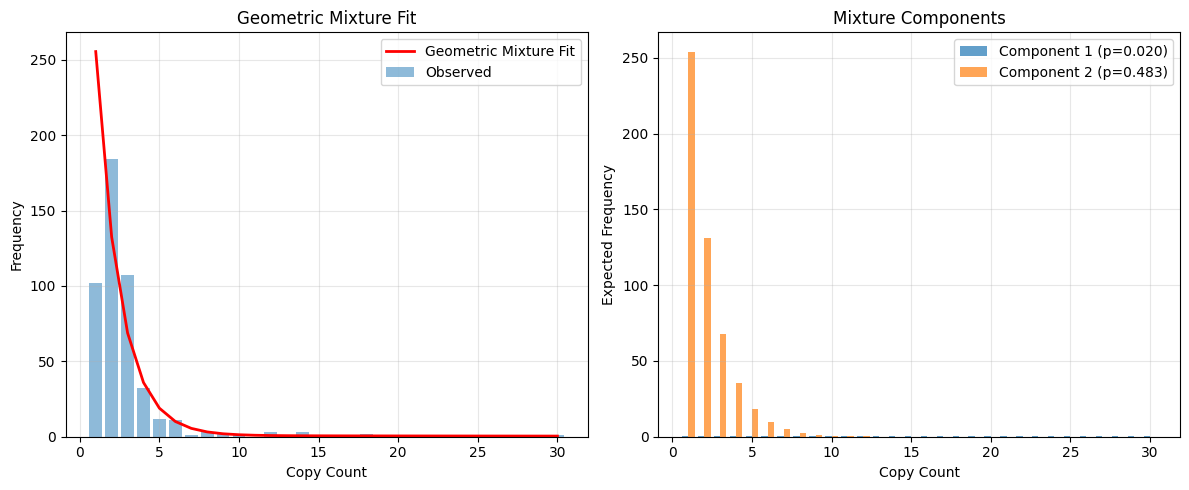

In [60]:
# ============================================================================
# MIXTURE COMPONENT VISUALIZATION
# Plot the overall fit and individual mixture components separately.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------- Plot 1: Overall Geometric Mixture Fit --------------------
axes[0].bar(all_vals[:30], observed[:30], alpha=0.5, label='Observed', width=0.8)
axes[0].plot(all_vals[:30], results['Geometric Mixture']['expected'][:30], 
            'r-', linewidth=2, label='Geometric Mixture Fit')
axes[0].set_title(f'Geometric Mixture Fit')
axes[0].set_xlabel('Copy Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -------------------- Plot 2: Individual Components --------------------
k = np.arange(1, 31)
# Component 1: weighted geometric distribution
geom1 = w * p1 * (1-p1)**(k-1) * n
# Component 2: weighted geometric distribution  
geom2 = (1-w) * p2 * (1-p2)**(k-1) * n

axes[1].bar(k-0.2, geom1, width=0.4, alpha=0.7, label=f'Component 1 (p={p1:.3f})')
axes[1].bar(k+0.2, geom2, width=0.4, alpha=0.7, label=f'Component 2 (p={p2:.3f})')
axes[1].set_title('Mixture Components')
axes[1].set_xlabel('Copy Count')
axes[1].set_ylabel('Expected Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Creating CDF comparison plot...


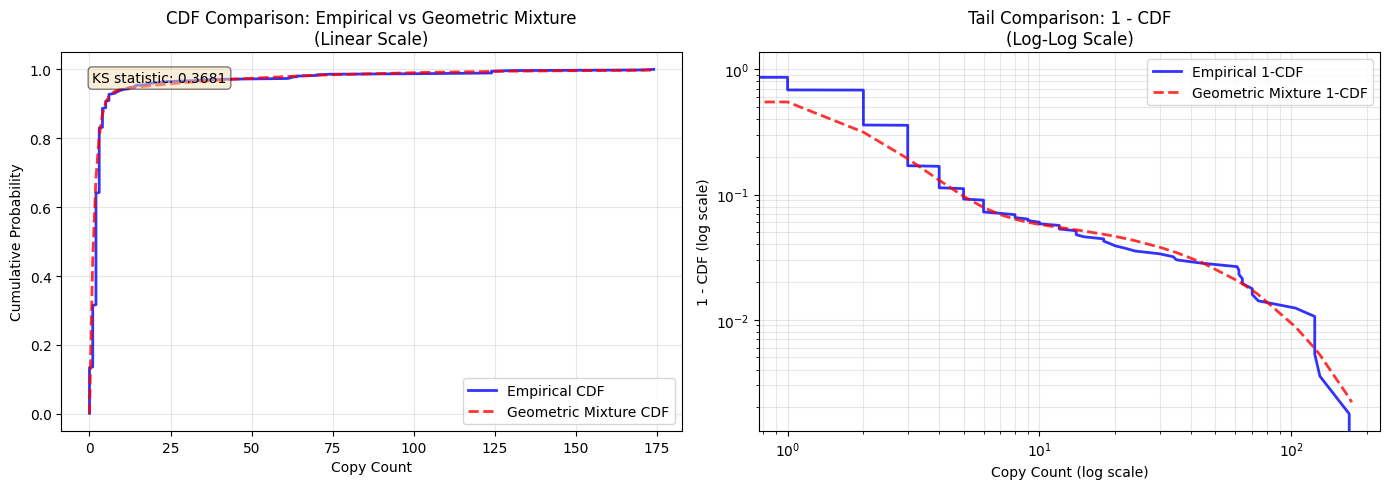


Creating QQ plot...


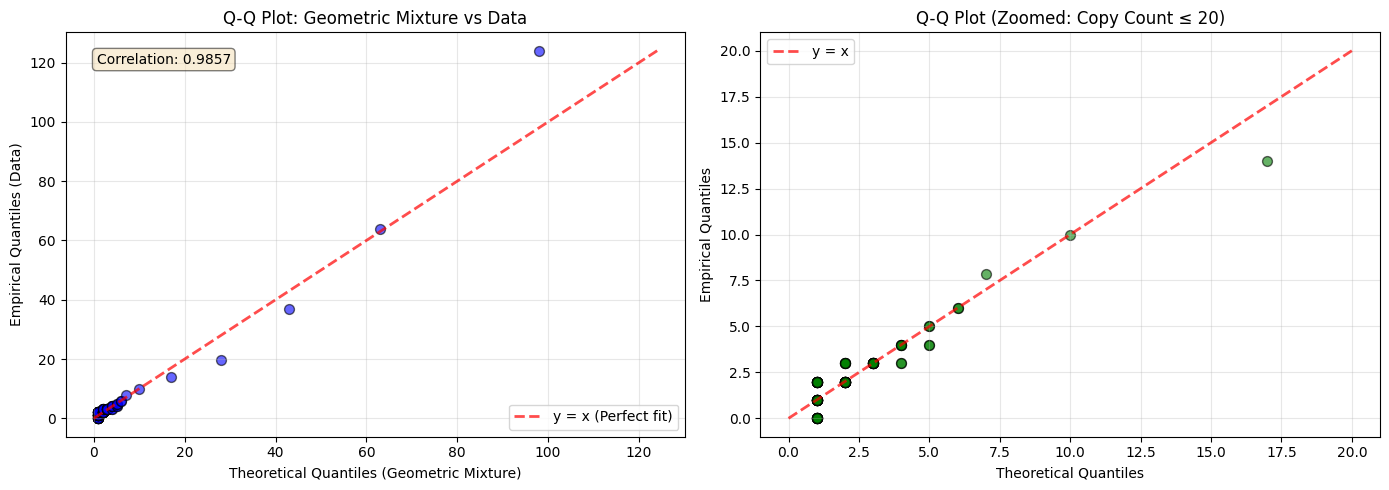


Creating PP plot...


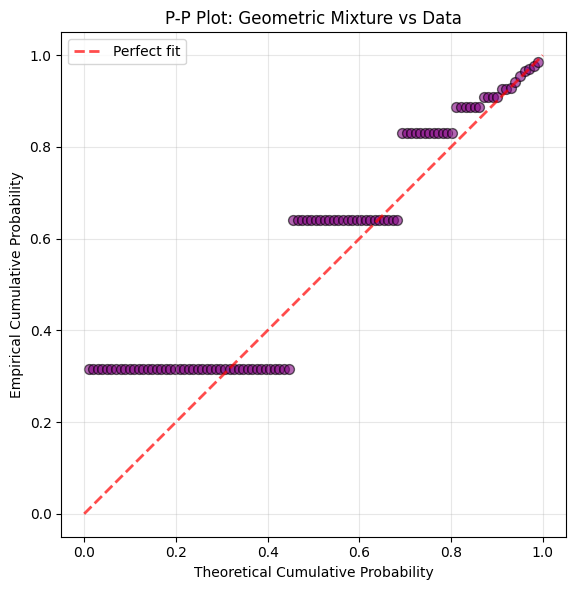


Performing simulation-based goodness-of-fit test...
  Completed 100/1000 simulations...
  Completed 200/1000 simulations...
  Completed 300/1000 simulations...
  Completed 400/1000 simulations...
  Completed 500/1000 simulations...
  Completed 600/1000 simulations...
  Completed 700/1000 simulations...
  Completed 800/1000 simulations...
  Completed 900/1000 simulations...
  Completed 1000/1000 simulations...

Simulation-based goodness-of-fit:
  Observed KS statistic: 0.3681
  Simulated p-value: 1.0000
  Mean KS from simulations: 0.4492
  95% of simulated KS are below: 0.4492


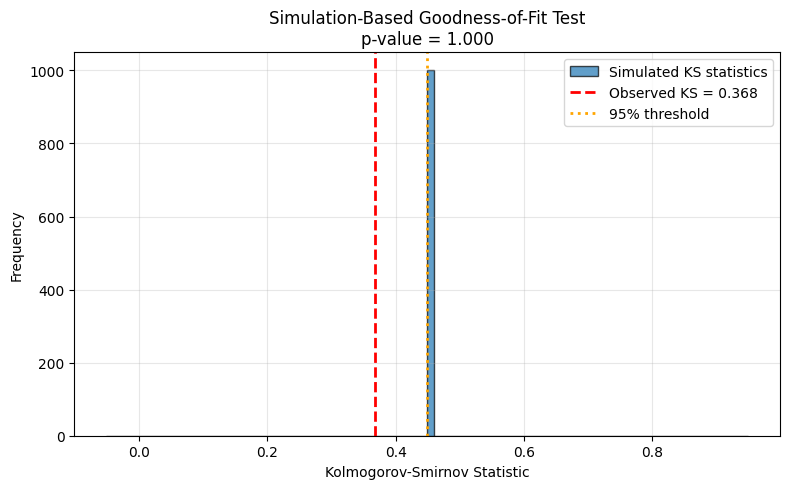


COMPREHENSIVE DIAGNOSTIC SUMMARY

1. DATA SUMMARY:
   Sample size: n = 565
   Min: 0, Max: 174
   Mean: 5.437, Variance: 317.014
   Variance/Mean ratio: 58.31

2. FITTED GEOMETRIC MIXTURE PARAMETERS:
   Mixing weight w = 0.069
   Component 1: p = 0.020, Mean = 50.99 copies
   Component 2: p = 0.483, Mean = 2.07 copies
   Overall model mean = 5.44 copies

3. GOODNESS-OF-FIT STATISTICS:
   KS statistic: 0.3681
   QQ plot correlation: 0.9857
   Simulation p-value: 1.0000

4. INTERPRETATION:
   ✓ Model is statistically adequate (p > 0.05)
   ✓ QQ plot shows strong linear relationship

5. RECOMMENDATION:
   Model provides excellent fit - use with confidence


In [61]:
# ============================================================================
# COMPREHENSIVE GOODNESS-OF-FIT DIAGNOSTICS
# Create CDF comparison, QQ plots, PP plots, and simulation-based tests
# to thoroughly evaluate the Geometric Mixture model fit.
# ============================================================================

# ==================== 1. CDF COMPARISON PLOT ====================
print("Creating CDF comparison plot...")

# Calculate empirical CDF (ECDF)
sorted_data = np.sort(data)
ecdf = np.arange(1, n + 1) / n

# Calculate theoretical CDF at each data point
theoretical_cdf = np.array([geometric_mixture_cdf(k, w, p1, p2) for k in sorted_data])

# Calculate KS statistic (maximum deviation between CDFs)
ks_stat = np.max(np.abs(ecdf - theoretical_cdf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1a: CDF comparison (linear scale)
axes[0].plot(sorted_data, ecdf, 'b-', linewidth=2, label='Empirical CDF', alpha=0.8)
axes[0].plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Geometric Mixture CDF', alpha=0.8)
axes[0].set_xlabel('Copy Count')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('CDF Comparison: Empirical vs Geometric Mixture\n(Linear Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'KS statistic: {ks_stat:.4f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 1b: Tail comparison (log-log scale)
axes[1].loglog(sorted_data, 1 - ecdf, 'b-', linewidth=2, label='Empirical 1-CDF', alpha=0.8)
axes[1].loglog(sorted_data, 1 - theoretical_cdf, 'r--', linewidth=2, 
              label='Geometric Mixture 1-CDF', alpha=0.8)
axes[1].set_xlabel('Copy Count (log scale)')
axes[1].set_ylabel('1 - CDF (log scale)')
axes[1].set_title('Tail Comparison: 1 - CDF\n(Log-Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ==================== 2. QUANTILE-QUANTILE (QQ) PLOT ====================
print("\nCreating QQ plot...")

# Create percentile grid (avoid 0 and 1 for finite quantiles)
percentiles = np.linspace(0.01, 0.99, 100)

# Calculate empirical and theoretical quantiles
empirical_quantiles = np.percentile(data, percentiles * 100)
theoretical_quantiles = np.array([geometric_mixture_quantile(q, w, p1, p2) for q in percentiles])

# Calculate QQ correlation
qq_corr = np.corrcoef(theoretical_quantiles, empirical_quantiles)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2a: Full QQ plot
max_val_qq = max(np.max(theoretical_quantiles), np.max(empirical_quantiles))
axes[0].scatter(theoretical_quantiles, empirical_quantiles, alpha=0.6, 
               color='blue', edgecolor='black', s=50)
axes[0].plot([0, max_val_qq], [0, max_val_qq], 'r--', linewidth=2, alpha=0.7, label='y = x (Perfect fit)')
axes[0].set_xlabel('Theoretical Quantiles (Geometric Mixture)')
axes[0].set_ylabel('Empirical Quantiles (Data)')
axes[0].set_title('Q-Q Plot: Geometric Mixture vs Data')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'Correlation: {qq_corr:.4f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2b: Zoomed QQ plot (focus on common values)
zoom_threshold = 20
zoom_mask = (theoretical_quantiles <= zoom_threshold) & (empirical_quantiles <= zoom_threshold)
axes[1].scatter(theoretical_quantiles[zoom_mask], empirical_quantiles[zoom_mask], 
               alpha=0.6, color='green', edgecolor='black', s=50)
axes[1].plot([0, zoom_threshold], [0, zoom_threshold], 'r--', linewidth=2, alpha=0.7, label='y = x')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Empirical Quantiles')
axes[1].set_title(f'Q-Q Plot (Zoomed: Copy Count ≤ {zoom_threshold})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 3. PP PLOT (Probability-Probability) ====================
print("\nCreating PP plot...")

# Calculate empirical probabilities at theoretical quantiles
empirical_probs_at_theoretical = np.array([
    np.mean(data <= geometric_mixture_quantile(prob, w, p1, p2))
    for prob in percentiles
])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(percentiles, empirical_probs_at_theoretical, alpha=0.6, 
          color='purple', edgecolor='black', s=50)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
ax.set_xlabel('Theoretical Cumulative Probability')
ax.set_ylabel('Empirical Cumulative Probability')
ax.set_title('P-P Plot: Geometric Mixture vs Data')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# ==================== 4. SIMULATION-BASED GOODNESS-OF-FIT TEST ====================
print("\nPerforming simulation-based goodness-of-fit test...")

n_simulations = 1000
simulated_ks_stats = []

for i in range(n_simulations):
    # Simulate data from fitted model
    sim_data = simulate_geometric_mixture(n, w, p1, p2)
    
    # Calculate simulated ECDF and theoretical CDF
    sim_sorted = np.sort(sim_data)
    sim_ecdf = np.arange(1, n + 1) / n
    sim_theoretical_cdf = np.array([geometric_mixture_cdf(k, w, p1, p2) for k in sim_sorted])
    
    # Store KS statistic
    simulated_ks_stats.append(np.max(np.abs(sim_ecdf - sim_theoretical_cdf)))
    
    if (i + 1) % 100 == 0:
        print(f"  Completed {i+1}/{n_simulations} simulations...")

simulated_ks_stats = np.array(simulated_ks_stats)

# Calculate simulation-based p-value
p_value_sim = np.mean(simulated_ks_stats >= ks_stat)

print(f"\nSimulation-based goodness-of-fit:")
print(f"  Observed KS statistic: {ks_stat:.4f}")
print(f"  Simulated p-value: {p_value_sim:.4f}")
print(f"  Mean KS from simulations: {np.mean(simulated_ks_stats):.4f}")
print(f"  95% of simulated KS are below: {np.percentile(simulated_ks_stats, 95):.4f}")

# Plot simulation results
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(simulated_ks_stats, bins=100, alpha=0.7, edgecolor='black', label='Simulated KS statistics')
ax.axvline(x=ks_stat, color='red', linewidth=2, linestyle='--', label=f'Observed KS = {ks_stat:.3f}')
ax.axvline(x=np.percentile(simulated_ks_stats, 95), color='orange', linewidth=2, linestyle=':', label='95% threshold')
ax.set_xlabel('Kolmogorov-Smirnov Statistic')
ax.set_ylabel('Frequency')
ax.set_title(f'Simulation-Based Goodness-of-Fit Test\np-value = {p_value_sim:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 5. COMPREHENSIVE DIAGNOSTIC SUMMARY ====================
print("\n" + "="*60)
print("COMPREHENSIVE DIAGNOSTIC SUMMARY")
print("="*60)

print(f"\n1. DATA SUMMARY:")
print(f"   Sample size: n = {n}")
print(f"   Min: {data.min()}, Max: {data.max()}")
print(f"   Mean: {data.mean():.3f}, Variance: {data.var():.3f}")
print(f"   Variance/Mean ratio: {data.var()/data.mean():.2f}")

print(f"\n2. FITTED GEOMETRIC MIXTURE PARAMETERS:")
print(f"   Mixing weight w = {w:.3f}")
print(f"   Component 1: p = {p1:.3f}, Mean = {1/p1:.2f} copies")
print(f"   Component 2: p = {p2:.3f}, Mean = {1/p2:.2f} copies")
print(f"   Overall model mean = {w*(1/p1) + (1-w)*(1/p2):.2f} copies")

print(f"\n3. GOODNESS-OF-FIT STATISTICS:")
print(f"   KS statistic: {ks_stat:.4f}")
print(f"   QQ plot correlation: {qq_corr:.4f}")
print(f"   Simulation p-value: {p_value_sim:.4f}")

print(f"\n4. INTERPRETATION:")
if p_value_sim > 0.05:
    print(f"   ✓ Model is statistically adequate (p > 0.05)")
else:
    print(f"   ✗ Model is statistically rejected (p < 0.05)")
    print(f"   (But still the best available among tested models)")

if qq_corr > 0.95:
    print(f"   ✓ QQ plot shows strong linear relationship")
elif qq_corr > 0.90:
    print(f"   ~ QQ plot shows moderate relationship")
else:
    print(f"   ✗ QQ plot shows weak relationship")

print(f"\n5. RECOMMENDATION:")
if p_value_sim > 0.05 and qq_corr > 0.95:
    print(f"   Model provides excellent fit - use with confidence")
elif p_value_sim > 0.01 and qq_corr > 0.90:
    print(f"   Model provides adequate fit for practical purposes")
else:
    print(f"   Model is best available but has significant limitations")
    print(f"   Use for general insights, not precise probability calculations")